# GeoTIFF to Cloud-Optimized GeoTIFF

This notebook shows how to a convert a plain GeoTIFF to a Cloud-Optimized GeoTIFF (COG). The conversion is done using `xarray` or `rasterio`. In addition, both formats are benchmarked with respect to windowed data access and the image pyramid capabilities of COG are demonstrated.

First, we import all required packages 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import pystac_client
import urllib.request
import rasterio
import matplotlib.pyplot as plt

from pathlib import Path
from timeit import timeit

from rasterio.windows import Window
from rasterio.io import MemoryFile
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles

import warnings
warnings.filterwarnings("ignore")

and create input and output folders locally.

In [2]:
gt_dirpath = Path('../data/01_s1_sigma0_geotiff')
cog_dirpath = Path('../outputs/01_s1_sigma0_cog')

gt_dirpath.mkdir(parents=True, exist_ok=True)
cog_dirpath.mkdir(parents=True, exist_ok=True)

Next, we define a function, which allows us to download all assets related to a STAC item.

In [3]:
def download_tif_assets(stac_api_url: str, outpath: Path, collection_id: str, item_id: str) -> None:
    session = pystac_client.Client.open(stac_api_url)
    collection = session.get_collection(collection_id)
    item = collection.get_item(id=item_id)

    if item is not None:
        for asset_key, asset in item.assets.items():
            fn = f'{item.id}_{asset_key}.tif'

            if 'thumbnail' in asset_key:
                continue

            urllib.request.urlretrieve(asset.href, outpath / fn)
    else:
        err_msg = f"Item '{item_id}' not found."
        raise pystac_client.exceptions.APIError(err_msg)

Then we use the function to download two GeoTIFF files from the "SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH" STAC item within eodc's "SENTINEL1_SIG0_20M" collection. The two files represent sigma nought backscatter at 20m sampling with different polarisations, i.e., "VV" and "VH". 

In [4]:
stac_api_url = "https://stac.eodc.eu/api/v1/"
download_tif_assets(stac_api_url=stac_api_url,
                    outpath=gt_dirpath, 
                    collection_id="SENTINEL1_SIG0_20M",
                    item_id="SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH")
list(gt_dirpath.glob("*"))

[PosixPath('../data/01_s1_sigma0_geotiff/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif'),
 PosixPath('../data/01_s1_sigma0_geotiff/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif')]

## Conversion

Now we can exploit different methods to convert a GeoTIFF to a COG file:
- `rio_cogeo` package with `rasterio`: rewrites the raster with blocksizes/tilings and overview levels/image pyramids
- `xarray` with `rioxarray`: rewrites the raster with similar settings, but less code overhead as its handled by `xarray`

Both of these packages wrap around `gdal_translate` so the process in the background is the same. Its important to consider data types, masking, and scaling as they are implemented/applied differently in `rasterio` and `xarray`. As we will see in the cells below, xarray works slighly faster.

### `rasterio`

Based on the following guide, we can convert the GeoTIFF files using `rasterio`: https://guide.cloudnativegeo.org/cloud-optimized-geotiffs/writing-cogs-in-python.html

In [5]:
for filepath in gt_dirpath.glob('*.tif'):
    new_filepath = cog_dirpath / f"rio_cogeo_{filepath.name}"
    
    with rasterio.open(filepath, mode='r') as src:
        # initialise meta parameters to add overviews
        src_profile = src.profile
        
        # init a memoryfile to write data into
        with MemoryFile() as memfile:
            with memfile.open(**src_profile) as mem:
                # write single band information -> adapt for multi-band use cases where you might not want to write everything
                mem.write(src.read())

                # the COG conversion magic happens here: recommendations are ZSTD, LZW, deflate for compression
                dst_profile = cog_profiles.get("ZSTD")

                # this is very important as the cog_profile assumes float32, which is not the case for S1 as its saved with int16 to reduce storage
                dst_profile.update({'dtype': src_profile['dtype']})

                # These profile parameters are set which annotate the raster and allow the optimised windowed reading
                
                # "driver": "GTiff",
                # "interleave": "pixel",
                # "tiled": True,
                # "blockxsize": 512, 
                # "blockysize": 512,
                # "compress": "DEFLATE",

                # Creating destination COG
                cog_translate(
                    mem,
                    new_filepath,
                    dst_profile,
                    use_cog_driver=True,
                    in_memory=False,
                    overview_level=4,
                    overview_resampling='nearest',
                    nodata=src.nodata,  # or with another newly defined nodata
                    quiet=True
                )

list(cog_dirpath.glob("*"))

[PosixPath('../outputs/01_s1_sigma0_cog/xarray_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif'),
 PosixPath('../outputs/01_s1_sigma0_cog/rio_cogeo_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif'),
 PosixPath('../outputs/01_s1_sigma0_cog/rio_cogeo_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif'),
 PosixPath('../outputs/01_s1_sigma0_cog/xarray_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif')]

### `xarray`

Now we can do the same with `xarray`:

In [6]:
for filepath in gt_dirpath.glob('*.tif'):
    new_filepath = cog_dirpath / f"xarray_{filepath.name}"

    da = rioxarray.open_rasterio(filepath)  # do not provide mask_and_scale=True to maintain int16

    da[0].rio.to_raster(
        new_filepath,
        compress="ZSTD",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        overview_count=4,
        overview_resampling='nearest',
        driver='COG',
        dtype=da.dtype, # set explicitly if required
    )

list(cog_dirpath.glob("*"))

[PosixPath('../outputs/01_s1_sigma0_cog/xarray_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif'),
 PosixPath('../outputs/01_s1_sigma0_cog/rio_cogeo_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif'),
 PosixPath('../outputs/01_s1_sigma0_cog/rio_cogeo_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif'),
 PosixPath('../outputs/01_s1_sigma0_cog/xarray_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif')]

## Benchmark

Lets perform some simple benchmarks in terms of comparing filesize and read access between GeoTIFF and COG.

### Filesize

When comparing the two formats with this specific dataset, the file size of the COG is approximately one third bigger than the GeoTIFF. This stems from the additional image pyramids stored next to the native data.

In [7]:
gt_vv_filepath = next(gt_dirpath.glob("*VV.tif"))
cog_vv_filepath = next(cog_dirpath.glob("*xarray*VV.tif"))

print(f"GeoTIFF size: {gt_vv_filepath.lstat().st_size / 1e6:.2f} [MB]")
print(f"COG size: {cog_vv_filepath.lstat().st_size / 1e6:.2f} [MB]")

GeoTIFF size: 95.48 [MB]
COG size: 122.48 [MB]


### Data access

To highlight differences in terms of read access, we provide several helper functions to perform and benchmark reading the whole dataset iteratively using a windowed `rasterio.DatasetReader`. We also create a benchmark function to retrieve or compute overviews on the fly.

In [8]:
def read_tif_windowed(ds: rasterio.DatasetReader, window_size: int) -> None:
    nrows, ncols = ds.shape
    for row in range(0, nrows, window_size):
        for col in range(0, ncols, window_size):
            ds.read(1, window=Window(*[col, row, min(window_size, ncols - col), min(window_size, nrows - row)]))


def benchmark_windowed_read(filepath: Path) -> pd.DataFrame:
    bm_dict = {"filepath": [str(filepath)]}
    with rasterio.open(filepath) as src:
        for x in [256, 512, 1048]:
            t_win = timeit(
                lambda: read_tif_windowed(src, x),
                number=10,
            )
            bm_dict[f'window_{x}_read'] = [round(t_win, 6)]

    return pd.DataFrame(bm_dict).set_index("filepath")


def benchmark_overview_read(filepath: Path) -> pd.DataFrame:
    bm_dict = {"filepath": [str(filepath)]}
    with rasterio.open(filepath) as src:
        for factor in [2, 4, 8]:
            t = timeit(
                lambda: src.read(
                    1,
                    out_shape=(
                        src.height // factor,
                        src.width // factor,
                    ),
                    resampling=rasterio.enums.Resampling.nearest,
                ),
                number=100,
            )
            bm_dict[f'overview_{factor}_access'] = [round(t, 6)]

    return pd.DataFrame(bm_dict).set_index("filepath")


def benchmark_tif(filepath: Path) -> pd.DataFrame:
    windowed_df = benchmark_windowed_read(filepath)
    overview_df = benchmark_overview_read(filepath)
    return pd.concat([windowed_df, overview_df], axis=1)

Using these functions we are now able to create a `DataFrame` containing the read access times (in seconds).

In [9]:
benchmark_dfs = []
for filepath in gt_dirpath.glob('*.tif'):
    benchmark_dfs.append(benchmark_tif(filepath))

for filepath in cog_dirpath.glob('*.tif'):
    benchmark_dfs.append(benchmark_tif(filepath))

benchmark_df = pd.concat(benchmark_dfs)
benchmark_df

,window_256_read,window_512_read,window_1048_read,overview_2_access,overview_4_access,overview_8_access
filepath,,,,,,
../data/01_s1_sigma0_geotiff/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif,2.466450,1.098446,0.676537,7.157017,1.598644,0.590571
../data/01_s1_sigma0_geotiff/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif,2.407346,1.121862,0.625169,6.540189,1.508091,0.567340
../outputs/01_s1_sigma0_cog/xarray_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif,2.485094,0.650262,0.543278,3.024550,0.444202,0.088578
../outputs/01_s1_sigma0_cog/rio_cogeo_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif,2.517079,0.817812,0.639252,2.444864,0.342040,0.073689
../outputs/01_s1_sigma0_cog/rio_cogeo_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif,2.170480,0.670396,0.539845,2.599921,0.361935,0.091325
../outputs/01_s1_sigma0_cog/xarray_SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif,2.174059,0.651438,0.555608,2.630992,0.354005,0.074852


The read access benchmarks show the following insights:
- windowed reading matching the tiling/block size pattern of the data provides the fastest access. There is a significant difference between the GeoTIFF and COG because the GeoTIFF files are tiled differently (15000x5 vs. 512x512). However, the actual benefit of COG becomes apparent when doing HTTP range requests on remote files, which was not performed here in this notebook. 
- reading in overviews instead of computing them in memory is much faster

## Image pyramids

Finally, we can plot the generated image pyramid/overview levels stored in the COG.

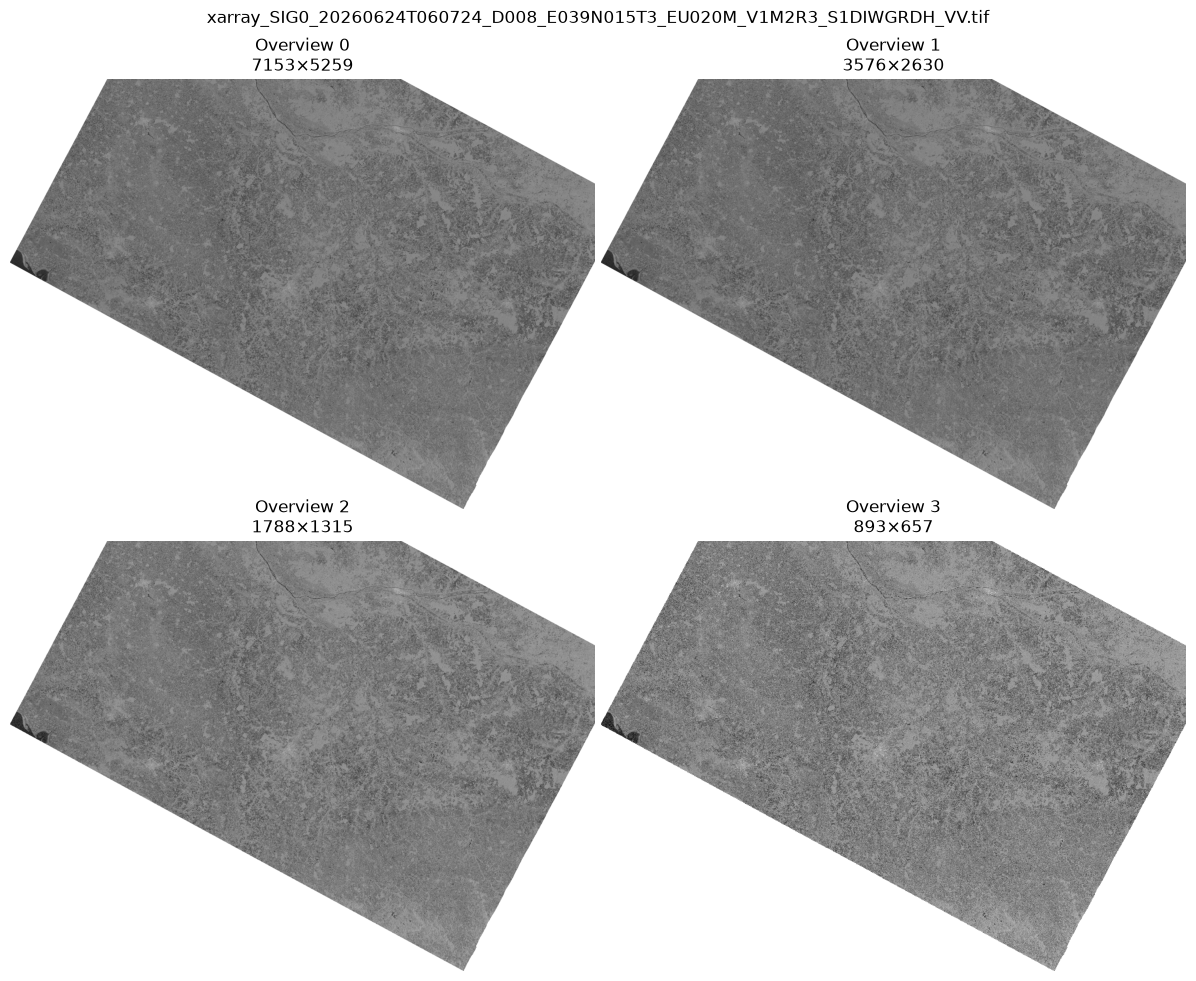

In [10]:
ref_cog_filepath = next(cog_dirpath.glob('*.tif'))

def crop_to_valid(arr: np.ndarray) -> np.ndarray:
    valid = ~np.isnan(arr)
    rows = np.any(valid, axis=1)
    cols = np.any(valid, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return arr[rmin:rmax + 1, cmin:cmax + 1]

overview_lvls = [0, 1, 2, 3]
arrays = []
for overview_lvl in overview_lvls:
    with rasterio.open(ref_cog_filepath, overview_level=overview_lvl) as src:
        arr = src.read()[0]
        arr = arr.astype(np.float32)
        arr[arr==-9999] = np.nan
        arr = crop_to_valid(arr)
        arrays.append(arr)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01, hspace=0.03, wspace=0.01)

for ax, arr, level in zip(axes.flat, arrays, overview_lvls):
    ax.imshow(arr, cmap="gray")
    ax.set_title("Full res" if level == -1 else f"Overview {level}\n{arr.shape[1]}×{arr.shape[0]}")
    ax.set_axis_off()

fig.suptitle(filepath.name)
plt.show()
